In [28]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import(

r2_score,mean_squared_error,mean_absolute_error
)

from python1 import X_test

Accuracy: 0.9111111111111111


In [6]:
import pandas as pd

data = {
    "area": [500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400,
             1500, 1600, 1700, 1800, 1900],

    "bedrooms": [1, 2, 2, 2, 3, 3, 3, 4, 4, 4,
                 4, 5, 5, 5, 6],

    "age": [20, 15, 10, 8, 12, 5, 7, 4, 6, 3,
            5, 2, 4, 1, 3],

    "location": [
        "Islamabad", "Rawalpindi", "Islamabad", "Lahore",
        "Islamabad", "Lahore", "Rawalpindi", "Islamabad",
        "Lahore", "Islamabad", "Rawalpindi", "Lahore",
        "Islamabad", "Rawalpindi", "Islamabad"
    ],

    "furnished": [
        "Yes", "No", "Yes", "No", "Yes",
        "Yes", "No", "Yes", "No", "Yes",
        "No", "Yes", "Yes", "No", "Yes"
    ],

    "price": [
        50, 58, 70, 75, 90,
        105, 110, 130, 135, 150,
        155, 175, 185, 195, 220
    ]
}

df = pd.DataFrame(data)

print(df)

    area  bedrooms  age    location furnished  price
0    500         1   20   Islamabad       Yes     50
1    600         2   15  Rawalpindi        No     58
2    700         2   10   Islamabad       Yes     70
3    800         2    8      Lahore        No     75
4    900         3   12   Islamabad       Yes     90
5   1000         3    5      Lahore       Yes    105
6   1100         3    7  Rawalpindi        No    110
7   1200         4    4   Islamabad       Yes    130
8   1300         4    6      Lahore        No    135
9   1400         4    3   Islamabad       Yes    150
10  1500         4    5  Rawalpindi        No    155
11  1600         5    2      Lahore       Yes    175
12  1700         5    4   Islamabad       Yes    185
13  1800         5    1  Rawalpindi        No    195
14  1900         6    3   Islamabad       Yes    220


In [7]:
X = df.drop("price", axis=1)

y = df["price"]

In [8]:
numerical_features = [
    "area",
    "bedrooms",
    "age"
]

categorical_features = [
    "location",
    "furnished"
]

In [10]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [11]:
preprocessor = ColumnTransformer([

    ("num", StandardScaler(), numerical_features),

    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("ridge", Ridge())
])

In [14]:
param_distributions = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100]
}

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
random_search=RandomizedSearchCV(

    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=3,
    cv=3,
    scoring="r2",
    random_state=42


)

In [31]:
random_search.fit(X_train, y_train)
results=pd.DataFrame(random_search.cv_results_)
print(results)

   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       0.009907      0.003901         0.005273        0.001393   
1       0.012063      0.009802         0.004483        0.001324   
2       0.005145      0.000407         0.002708        0.000145   

   param_ridge__alpha                 params  split0_test_score  \
0                 0.1  {'ridge__alpha': 0.1}           0.962786   
1               100.0  {'ridge__alpha': 100}           0.278449   
2                 1.0    {'ridge__alpha': 1}           0.995699   

   split1_test_score  split2_test_score  mean_test_score  std_test_score  \
0           0.974972           0.993675         0.977144        0.012703   
1           0.345178           0.282879         0.302169        0.030466   
2           0.966611           0.994105         0.985472        0.013352   

   rank_test_score  
0                2  
1                3  
2                1  


In [22]:
print("Best_parameter")
print(random_search.best_params_)

Best_parameter
{'ridge__alpha': 1}


In [23]:
print("Best cv score")
print(random_search.best_score_)

Best cv score
0.9854720628839558


In [24]:
best_model=random_search.best_estimator_

In [25]:
predict=best_model.predict(X_test)

In [29]:
from sklearn.metrics import r2_score, mean_absolute_error

print("Test R²:", r2_score(y_test, predict))
print("MAE:", mean_absolute_error(y_test, predict))

Test R²: 0.9284950185220995
MAE: 9.122723788921514


# CV_results

In [32]:
results = pd.DataFrame(random_search.cv_results_)

print(
    results[
        [
            "param_ridge__alpha",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
)

   param_ridge__alpha  mean_test_score  std_test_score  rank_test_score
0                 0.1         0.977144        0.012703                2
1               100.0         0.302169        0.030466                3
2                 1.0         0.985472        0.013352                1


In [33]:
results = results.sort_values(
    "mean_test_score",
    ascending=False
)

print(
    results[
        [
            "param_ridge__alpha",
            "mean_test_score",
            "rank_test_score"
        ]
    ]
)

   param_ridge__alpha  mean_test_score  rank_test_score
2                 1.0         0.985472                1
0                 0.1         0.977144                2
1               100.0         0.302169                3


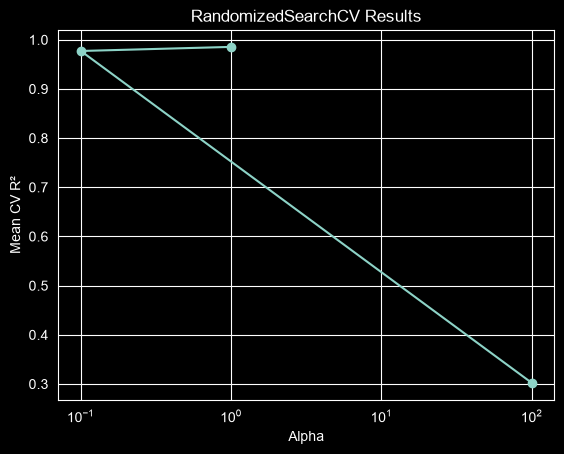

In [34]:
import matplotlib.pyplot as plt

plt.plot(
    results["param_ridge__alpha"].astype(float),
    results["mean_test_score"],
    marker="o"
)

plt.xlabel("Alpha")
plt.ylabel("Mean CV R²")
plt.title("RandomizedSearchCV Results")

plt.xscale("log")

plt.show()